# Optimal linear patch denoiser (translation-invariant power-law field)

Forward diffusion on a Gaussian field with covariance $\Sigma$:
$\phi_t = \sqrt{\alpha_t}\,x_0 + \sqrt{\beta_t}\,\eta$ with $\beta_t = 1-\alpha_t$ and $\eta \sim \mathcal{N}(0,I)$.
The linear score is
$$s_t(\phi) = -(\alpha_t \Sigma + \beta_t I)^{-1}\phi,$$
and the clean estimate is $\hat x_0 = (\phi - \beta_t s_t(\phi))/\sqrt{\alpha_t}$.

On each $L\times L$ patch we replace $\Sigma$ by the stationary patch covariance $P\Sigma P$ and take the **center pixel** of the patch-wise $\hat x_0$. $L$ is a user-defined function of the noise level.

The notebook:
1. Builds $\Sigma$ and patch covariances
2. Denoises / generates images with the patch Wiener filter
3. Compares radial mean Fourier power \(P(k)\) vs \(|k|\) for theory \(\Sigma\), data, and generated samples

In [1]:
import math
import os
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

os.chdir("../")
ROOT = Path(os.path.abspath("")).resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Configuration

In [2]:
dataset_name = "Power-law field"

image_height = 32
image_width = 32
image_size = image_height  # square grid helper (H == W)
alpha = 1.7  # spectral ~ |k|^{-alpha}  => spatial C(r) ~ r^{-(2-alpha)} for alpha != 2
sigma_sq = 1.0  # variance on diagonal / scale of two-point function
amplitude = 1.0

n_data_samples = 512  # samples from the GP for reference / empirical cov
n_gen_samples = 256   # generated images for covariance comparison

# Patch size as a function of noise level (odd integer >= 3)
def L_kernel_size(sigma_t: float, height: int, width: int) -> int:
    """User-defined patch side length L(sigma_t). Must be odd.

    `height` and `width` are the full image dimensions (pixels).
    """
    h = int(height)
    w = int(width)
    max_length = min(h, w)
    alpha_prime = 1.0
    L = int(np.ceil(max_length * (float(sigma_t) ** (2.0 / alpha_prime))))
    L = max(L, 3)
    if L % 2 == 0:
        L += 1
    cap = max_length if max_length % 2 else max_length - 1
    return min(L, cap)

# Single noise level for one-shot denoise demo (diffusion parameterization)
alpha_t_demo = 0.5
beta_t_demo = 1.0 - alpha_t_demo

# Reverse diffusion: alpha_t increases from noisy (small alpha) to clean (near 1)
n_diffusion_steps = 12
alpha_schedule = np.linspace(0.02, 0.995, n_diffusion_steps + 1)
# Reverse process is deterministic (no extra sampling noise); steps scale with d alpha_t

## Covariance construction and patch Wiener weights

In [3]:
def power_law_toeplitz_covariance(
    image_height: int,
    image_width: int | None = None,
    alpha: float = 1.7,
    sigma_sq: float = 1.0,
    amplitude: float = 1.0,
    lattice_spacing: float = 1.0,
    jitter: float = 1e-4,
    dtype=torch.float64,
):
    """Full N×N covariance on an H×W grid (translationally invariant kernel)."""
    if image_width is None:
        image_width = image_height
    H, W = int(image_height), int(image_width)
    n_pix = H * W
    ys = torch.arange(H, dtype=dtype)
    xs = torch.arange(W, dtype=dtype)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    coords = torch.stack([yy.reshape(-1), xx.reshape(-1)], dim=1)
    r = torch.cdist(coords, coords, p=2)
    r_safe = torch.clamp(r, min=lattice_spacing)
    if abs(alpha - 2.0) < 1e-8:
        C = amplitude * torch.log(r_safe)
    else:
        C = amplitude / (r_safe ** (2.0 - alpha))
    idx = torch.arange(n_pix)
    C[idx, idx] = sigma_sq
    C = 0.5 * (C + C.T) + jitter * torch.eye(n_pix, dtype=dtype)
    return C


def stationary_patch_covariance(
    kernel_size: int,
    alpha: float,
    sigma_sq: float,
    amplitude: float = 1.0,
    lattice_spacing: float = 1.0,
    dtype=torch.float64,
):
    """L×L patch covariance for interior patches (depends only on relative offsets)."""
    k = kernel_size
    off = torch.arange(k, dtype=dtype) - (k - 1) / 2.0
    oy, ox = torch.meshgrid(off, off, indexing="ij")
    # Build patch matrix from distances between patch indices
    coords = torch.stack([oy.reshape(-1), ox.reshape(-1)], dim=1)
    d = torch.cdist(coords, coords, p=2)
    d_safe = torch.clamp(d, min=lattice_spacing)
    if abs(alpha - 2.0) < 1e-8:
        C_patch = amplitude * torch.log(d_safe)
    else:
        C_patch = amplitude / (d_safe ** (2.0 - alpha))
    idx = torch.arange(k * k)
    C_patch[idx, idx] = sigma_sq
    C_patch = 0.5 * (C_patch + C_patch.T)
    return C_patch


def sample_gaussian_field_from_cov(C: torch.Tensor, n_samples: int, device=None):
    """x ~ N(0, C) via spectral factorization."""
    if device is None:
        device = C.device
    eigvals, eigvecs = torch.linalg.eigh(C)
    lam = torch.clamp(eigvals, min=1e-6)
    L = eigvecs @ torch.diag(torch.sqrt(lam))
    n_pix = C.shape[0]
    z = torch.randn(n_samples, n_pix, device=device, dtype=torch.float32)
    x = z @ L.T.to(torch.float32)
    h = int(round(np.sqrt(n_pix)))
    w = n_pix // h
    return x.view(n_samples, 1, h, w)


def radial_power_bins(height: int, width: int, device="cpu"):
    """Return flattened |k| and bin index for each Fourier mode on an H×W grid."""
    ky = torch.fft.fftfreq(height, d=1.0, device=device)
    kx = torch.fft.fftfreq(width, d=1.0, device=device)
    ky2d, kx2d = torch.meshgrid(ky, kx, indexing="ij")
    k_mag = torch.sqrt(kx2d**2 + ky2d**2).reshape(-1)
    k_np = k_mag.detach().cpu().numpy()
    k_pos = k_np[k_np > 0]
    if k_pos.size == 0:
        edges = np.array([0.0, 1.0])
    else:
        edges = np.logspace(np.log10(k_pos.min()), np.log10(k_pos.max()), 28)
    bin_idx = np.digitize(k_np, edges) - 1
    bin_idx = np.clip(bin_idx, 0, len(edges) - 2)
    k_centers = np.sqrt(edges[:-1] * edges[1:])
    return k_np, bin_idx, k_centers, edges


def radial_power_from_images(images: torch.Tensor, bin_idx: np.ndarray, n_bins: int):
    """Azimuthally averaged E[|x̂(k)|^2] from sample images."""
    n, _, h, w = images.shape
    fft_coeff = torch.fft.fft2(images, norm="ortho")
    power = (fft_coeff.abs() ** 2).mean(dim=0).reshape(-1)
    p = power.detach().cpu().numpy()
    sums = np.zeros(n_bins, dtype=np.float64)
    counts = np.zeros(n_bins, dtype=np.int64)
    np.add.at(sums, bin_idx, p)
    np.add.at(counts, bin_idx, 1)
    counts = np.maximum(counts, 1)
    return sums / counts


def radial_power_from_covariance(C: torch.Tensor, height: int, width: int, bin_idx: np.ndarray, n_bins: int):
    """Radial power from stationary covariance (Wiener–Khinchin on first covariance row)."""
    kernel = C[0].reshape(height, width).double().cpu()
    kernel = torch.fft.ifftshift(kernel)
    spec = torch.fft.fft2(kernel, norm="ortho")
    p = (spec.abs() ** 2).reshape(-1).numpy()
    sums = np.zeros(n_bins, dtype=np.float64)
    counts = np.zeros(n_bins, dtype=np.int64)
    np.add.at(sums, bin_idx, p)
    np.add.at(counts, bin_idx, 1)
    counts = np.maximum(counts, 1)
    return sums / counts


def theory_radial_power(k_centers: np.ndarray, alpha: float, amplitude: float = 1.0):
    """Reference P(k) ~ amplitude * |k|^{-alpha} on the binned |k| axis."""
    k = np.maximum(k_centers, 1e-12)
    return amplitude * (k ** (-alpha))


def empirical_covariance_from_images(images: torch.Tensor) -> torch.Tensor:
    """images: (N, 1, H, W) -> (HW, HW) sample covariance."""
    n, c, h, w = images.shape
    flat = images.reshape(n, -1).double()
    flat = flat - flat.mean(dim=0, keepdim=True)
    return (flat.T @ flat) / max(n - 1, 1)


def center_index(kernel_size: int) -> int:
    c = kernel_size // 2
    return c * kernel_size + c


@torch.no_grad()
def patch_linear_score_patches(
    phi: torch.Tensor,
    alpha_t: float,
    C_patch: torch.Tensor,
    kernel_size: int,
) -> torch.Tensor:
    """Patch score s = -(alpha_t C_patch + beta_t I)^{-1} phi on each unfolded patch."""
    alpha_t = float(alpha_t)
    beta_t = 1.0 - alpha_t
    k = kernel_size
    pad = k // 2
    patches = F.unfold(phi, k, padding=pad)  # (B, P, N)
    P = patches.shape[1]
    A = alpha_t * C_patch + beta_t * torch.eye(P, dtype=C_patch.dtype, device=C_patch.device)
    A = A.to(patches.dtype).to(patches.device)
    return -torch.linalg.solve(A, patches)


@torch.no_grad()
def optimal_patch_denoise(
    phi: torch.Tensor,
    alpha_t: float,
    field_alpha: float,
    sigma_sq: float,
    kernel_size: int,
    device=None,
) -> torch.Tensor:
    """x0_hat from phi_t: center pixel of (phi - beta_t s_t(phi)) / sqrt(alpha_t)."""
    if device is None:
        device = phi.device
    alpha_t = float(alpha_t)
    beta_t = 1.0 - alpha_t
    if beta_t < 1e-12:
        return phi
    k = kernel_size
    C_patch = stationary_patch_covariance(k, field_alpha, sigma_sq).to(device)
    s_patches = patch_linear_score_patches(phi, alpha_t, C_patch, k)
    pad = k // 2
    patches = F.unfold(phi, k, padding=pad)
    x0_patches = (patches - beta_t * s_patches) / math.sqrt(alpha_t)
    B = phi.shape[0]
    ci = center_index(k)
    return x0_patches[:, ci, :].view(B, 1, phi.shape[2], phi.shape[3])


@torch.no_grad()
def patch_estimate_x0_given_xt(
    x_t: torch.Tensor,
    alpha_t: float,
    field_alpha: float,
    sigma_sq: float,
    img_h: int,
    img_w: int,
    device=None,
) -> torch.Tensor:
    """Patch estimate of x_0 from x_t = sqrt(alpha_t) x_0 + sqrt(beta_t) eta."""
    beta_t = 1.0 - float(alpha_t)
    k = L_kernel_size(math.sqrt(beta_t), img_h, img_w)
    return optimal_patch_denoise(
        x_t, alpha_t, field_alpha, sigma_sq, k, device=device
    )


@torch.no_grad()
def patch_noise_expectation(
    x_t: torch.Tensor,
    alpha_t: float,
    field_alpha: float,
    sigma_sq: float,
    img_h: int,
    img_w: int,
    device=None,
) -> torch.Tensor:
    """E[eta | x_t] for x_t = sqrt(alpha_t) x_0 + sqrt(1-alpha_t) eta, eta ~ N(0,I)."""
    alpha_t = float(alpha_t)
    beta_t = 1.0 - alpha_t
    if beta_t < 1e-12:
        return torch.zeros_like(x_t)
    x0_hat = patch_estimate_x0_given_xt(
        x_t, alpha_t, field_alpha, sigma_sq, img_h, img_w, device=device
    )
    return (x_t - math.sqrt(alpha_t) * x0_hat) / math.sqrt(beta_t)


@torch.no_grad()
def patch_velocity_field(
    phi: torch.Tensor,
    alpha_t: float,
    field_alpha: float,
    sigma_sq: float,
    img_h: int,
    img_w: int,
    device=None,
) -> torch.Tensor:
    """v(phi) = phi + s(phi) with linear score s(phi) = -(alpha_t Sigma + beta_t I)^{-1} phi."""
    beta_t = 1.0 - float(alpha_t)
    if beta_t < 1e-12:
        return phi
    return phi + patch_diffusion_score(
        phi, alpha_t, field_alpha, sigma_sq, img_h, img_w, device=device
    )


@torch.no_grad()
def patch_diffusion_score(
    x_t: torch.Tensor,
    alpha_t: float,
    field_alpha: float,
    sigma_sq: float,
    img_h: int,
    img_w: int,
    device=None,
) -> torch.Tensor:
    """Patch linear score s_t(phi) = -(alpha_t Sigma + beta_t I)^{-1} phi (center pixel per patch)."""
    beta_t = 1.0 - float(alpha_t)
    if beta_t < 1e-12:
        return torch.zeros_like(x_t)
    k = L_kernel_size(math.sqrt(beta_t), img_h, img_w)
    C_patch = stationary_patch_covariance(k, field_alpha, sigma_sq).to(device or x_t.device)
    s_patches = patch_linear_score_patches(x_t, alpha_t, C_patch, k)
    ci = center_index(k)
    B = x_t.shape[0]
    return s_patches[:, ci, :].view(B, 1, x_t.shape[2], x_t.shape[3])


def _images_to_flat(phi: torch.Tensor) -> torch.Tensor:
    """(B, 1, H, W) -> (B, N) with N = H*W."""
    return phi.reshape(phi.shape[0], -1)


def _flat_to_images(flat: torch.Tensor, height: int, width: int) -> torch.Tensor:
    return flat.reshape(flat.shape[0], 1, height, width)


@torch.no_grad()
def full_image_diffusion_operator(
    alpha_t: float,
    C_full: torch.Tensor,
    dtype=None,
    device=None,
) -> torch.Tensor:
    """A_t = alpha_t Sigma + beta_t I for the full grid."""
    alpha_t = float(alpha_t)
    beta_t = 1.0 - alpha_t
    if device is None:
        device = C_full.device
    if dtype is None:
        dtype = C_full.dtype
    n = C_full.shape[0]
    return alpha_t * C_full.to(device=device, dtype=dtype) + beta_t * torch.eye(
        n, device=device, dtype=dtype
    )


@torch.no_grad()
def full_image_linear_score(
    phi: torch.Tensor,
    alpha_t: float,
    C_full: torch.Tensor,
) -> torch.Tensor:
    """s(phi) = -(alpha_t Sigma + beta_t I)^{-1} phi on the full image (all pixels)."""
    flat = _images_to_flat(phi).T  # (N, B)
    A = full_image_diffusion_operator(alpha_t, C_full, dtype=flat.dtype, device=flat.device)
    s_flat = -torch.linalg.solve(A, flat)
    return _flat_to_images(s_flat.T, phi.shape[2], phi.shape[3])


@torch.no_grad()
def full_image_x0_estimate(
    phi: torch.Tensor,
    alpha_t: float,
    C_full: torch.Tensor,
) -> torch.Tensor:
    """x0_hat = (phi - beta_t s(phi)) / sqrt(alpha_t) with full-image s(phi)."""
    alpha_t = float(alpha_t)
    beta_t = 1.0 - alpha_t
    if beta_t < 1e-12:
        return phi
    s = full_image_linear_score(phi, alpha_t, C_full)
    return (phi - beta_t * s) / math.sqrt(alpha_t)


@torch.no_grad()
def marginal_covariance_at_alpha(alpha_t: float, C_full: torch.Tensor) -> torch.Tensor:
    """Cov(phi_t) = alpha_t Sigma + beta_t I for phi_t = sqrt(alpha_t) x_0 + sqrt(beta_t) eta."""
    alpha_t = float(alpha_t)
    beta_t = 1.0 - alpha_t
    n = C_full.shape[0]
    return alpha_t * C_full + beta_t * torch.eye(n, dtype=C_full.dtype, device=C_full.device)


@torch.no_grad()
def sample_phi_at_alpha(
    alpha_t: float,
    C_full: torch.Tensor,
    n_samples: int,
    image_height: int,
    image_width: int,
    device=None,
) -> torch.Tensor:
    """phi ~ N(0, alpha_t Sigma + beta_t I)."""
    C_marg = marginal_covariance_at_alpha(alpha_t, C_full)
    return sample_gaussian_field_from_cov(C_marg, n_samples, device=device).view(
        n_samples, 1, int(image_height), int(image_width)
    )


@torch.no_grad()
def full_image_velocity_field(
    phi: torch.Tensor,
    alpha_t: float,
    C_full: torch.Tensor,
) -> torch.Tensor:
    """v(phi) = phi + s(phi) with full-image linear score."""
    alpha_t = float(alpha_t)
    beta_t = 1.0 - alpha_t
    if beta_t < 1e-12:
        return phi
    return phi + full_image_linear_score(phi, alpha_t, C_full)


@torch.no_grad()
def generate_with_full_image_ode(
    alpha_schedule,
    C_full: torch.Tensor,
    n_samples: int,
    image_height: int,
    image_width: int,
    device=None,
):
    """Euler in alpha for d phi/d alpha = v(phi). Does not match DDIM / exact marginals."""
    if device is None:
        device = C_full.device
    img_h, img_w = int(image_height), int(image_width)
    alphas = np.asarray(alpha_schedule, dtype=np.float64)
    if alphas.size < 2:
        raise ValueError("alpha_schedule must have at least two values")
    if alphas[0] > alphas[-1]:
        alphas = alphas[::-1]
    phi = sample_phi_at_alpha(alphas[0], C_full, n_samples, img_h, img_w, device=device)
    for i in range(len(alphas) - 1):
        alpha_t = float(alphas[i])
        d_alpha = float(alphas[i + 1] - alphas[i])
        if 1.0 - alpha_t < 1e-12:
            continue
        phi = phi + d_alpha * full_image_velocity_field(phi, alpha_t, C_full)
    return phi


@torch.no_grad()
def generate_with_full_image_ddim(
    alpha_schedule,
    C_full: torch.Tensor,
    n_samples: int,
    image_height: int,
    image_width: int,
    device=None,
):
    """Deterministic reverse: keep eta_hat fixed, x0_hat from full linear posterior."""
    if device is None:
        device = C_full.device
    img_h, img_w = int(image_height), int(image_width)
    alphas = np.asarray(alpha_schedule, dtype=np.float64)
    if alphas.size < 2:
        raise ValueError("alpha_schedule must have at least two values")
    if alphas[0] > alphas[-1]:
        alphas = alphas[::-1]
    phi = sample_phi_at_alpha(alphas[0], C_full, n_samples, img_h, img_w, device=device)
    for i in range(len(alphas) - 1):
        alpha_t = float(alphas[i])
        alpha_next = float(alphas[i + 1])
        beta_t = 1.0 - alpha_t
        beta_next = 1.0 - alpha_next
        if beta_t < 1e-12:
            continue
        x0_hat = full_image_x0_estimate(phi, alpha_t, C_full)
        eta_hat = (phi - math.sqrt(alpha_t) * x0_hat) / math.sqrt(beta_t)
        phi = math.sqrt(alpha_next) * x0_hat + math.sqrt(beta_next) * eta_hat
    return phi


def generate_with_full_image_denoiser(
    *args,
    **kwargs,
):
    """Alias for full-image DDIM (recommended)."""
    return generate_with_full_image_ddim(*args, **kwargs)


@torch.no_grad()
def generate_with_patch_ddim(
    alpha_schedule,
    field_alpha: float,
    sigma_sq: float,
    n_samples: int,
    image_height: int,
    image_width: int,
    device=None,
    C_full: torch.Tensor | None = None,
):
    """DDIM reverse with patch x0_hat; init phi ~ N(0, alpha_0 Sigma + beta_0 I) if C_full given."""
    if device is None:
        device = torch.device("cpu")
    img_h, img_w = int(image_height), int(image_width)
    alphas = np.asarray(alpha_schedule, dtype=np.float64)
    if alphas.size < 2:
        raise ValueError("alpha_schedule must have at least two values")
    if alphas[0] > alphas[-1]:
        alphas = alphas[::-1]
    if C_full is not None:
        phi = sample_phi_at_alpha(alphas[0], C_full, n_samples, img_h, img_w, device=device)
    else:
        phi = torch.randn(n_samples, 1, img_h, img_w, device=device)
    for i in range(len(alphas) - 1):
        alpha_t = float(alphas[i])
        alpha_next = float(alphas[i + 1])
        beta_t = 1.0 - alpha_t
        beta_next = 1.0 - alpha_next
        if beta_t < 1e-12:
            continue
        x0_hat = patch_estimate_x0_given_xt(
            phi, alpha_t, field_alpha, sigma_sq, img_h, img_w, device=device
        )
        eta_hat = (phi - math.sqrt(alpha_t) * x0_hat) / math.sqrt(beta_t)
        phi = math.sqrt(alpha_next) * x0_hat + math.sqrt(beta_next) * eta_hat
    return phi


@torch.no_grad()
def generate_with_patch_denoiser(
    *args,
    **kwargs,
):
    """Alias for patch DDIM (recommended)."""
    return generate_with_patch_ddim(*args, **kwargs)


## Build $\Sigma$, sample data, and cache Wiener matrices

In [4]:
C_full = power_law_toeplitz_covariance(
    image_height, image_width, alpha=alpha, sigma_sq=sigma_sq, amplitude=amplitude
).to(device)

data_images = sample_gaussian_field_from_cov(C_full, n_data_samples, device=device)
C_emp_data = empirical_covariance_from_images(data_images.cpu())

k_demo = L_kernel_size(math.sqrt(beta_t_demo), image_height, image_width)

print(
    f"{dataset_name}: C_full {tuple(C_full.shape)}, demo patch k={k_demo}, "
    f"alpha_t={alpha_t_demo}"
)

Power-law field: C_full (1024, 1024), demo patch k=17, alpha_t=0.5


## One-step denoising and multi-step generation

In [5]:
# Noisy observations: phi_t = sqrt(alpha_t) x_0 + sqrt(beta_t) eta
x0_demo = data_images[: min(8, n_data_samples)]
eta = torch.randn_like(x0_demo)
phi_demo = math.sqrt(alpha_t_demo) * x0_demo + math.sqrt(beta_t_demo) * eta
x_hat_demo = optimal_patch_denoise(
    phi_demo, alpha_t_demo, alpha, sigma_sq, k_demo, device=device
)

gen_images = generate_with_patch_denoiser(
    alpha_schedule,
    alpha,
    sigma_sq,
    n_gen_samples,
    image_height,
    image_width,
    device=device,
    C_full=C_full,
)
C_emp_gen = empirical_covariance_from_images(gen_images.cpu())

## Generation sanity checks (full image vs patch, ODE vs DDIM)

The α-ODE `φ ← φ + Δα v(φ)` with `v(φ)=φ−E[η|φ]/√β` is **not** the same as carrying a fixed noise vector through the forward model; **DDIM** (`φ_{k+1}=√α_{k+1} x̂_0+√β_{k+1} η̂`) matches that continuation. We also compare to direct `x_0∼N(0,Σ)` samples and a fixed-latent forward path `φ(α)=√α x_0+√β η`.

In [6]:
def mean_neighbor_corr(images: torch.Tensor) -> float:
    x = images[:, 0].double()
    a = x[:, :, :-1].reshape(-1)
    b = x[:, :, 1:].reshape(-1)
    a = a - a.mean()
    b = b - b.mean()
    return float((a * b).mean() / (a.std() * b.std() + 1e-12))

# Gold standard: sample x_0 ~ N(0, Sigma) directly
gen_direct = sample_gaussian_field_from_cov(C_full, n_gen_samples, device=device)

# DDIM reverse (recommended) — init from marginal at alpha_0
gen_images_full = generate_with_full_image_ddim(
    alpha_schedule, C_full, n_gen_samples, image_height, image_width, device=device
)
gen_images_patch = generate_with_patch_ddim(
    alpha_schedule, alpha, sigma_sq, n_gen_samples, image_height, image_width,
    device=device, C_full=C_full,
)

# Broken reference: alpha-ODE (same bug for patch and full)
gen_full_ode = generate_with_full_image_ode(
    alpha_schedule, C_full, n_gen_samples, image_height, image_width, device=device
)

# Fixed latents forward path (must stay smooth)
x0_lat = data_images[0:1]
eta_lat = torch.randn_like(x0_lat)
phi_forward = []
for a in alpha_schedule:
    b = 1.0 - float(a)
    phi_forward.append(math.sqrt(float(a)) * x0_lat + math.sqrt(b) * eta_lat)
phi_forward_last = phi_forward[-1]

print(f"{dataset_name} mean row neighbor correlation:")
print(f"  data (GP):       {mean_neighbor_corr(data_images[:n_gen_samples]):.4f}")
print(f"  direct Sigma:    {mean_neighbor_corr(gen_direct):.4f}")
print(f"  full DDIM:       {mean_neighbor_corr(gen_images_full):.4f}")
print(f"  patch DDIM:      {mean_neighbor_corr(gen_images_patch):.4f}")
print(f"  full alpha-ODE:  {mean_neighbor_corr(gen_full_ode):.4f}")
print(f"  patch alpha-ODE: {mean_neighbor_corr(gen_images):.4f}")
print(f"  forward path:    {mean_neighbor_corr(phi_forward_last):.4f}")

Power-law field mean row neighbor correlation:
  data (GP):       0.9289
  direct Sigma:    0.9293
  full DDIM:       -0.2659
  patch DDIM:      -0.4798
  full alpha-ODE:  0.0696
  patch alpha-ODE: -0.4704
  forward path:    0.8636


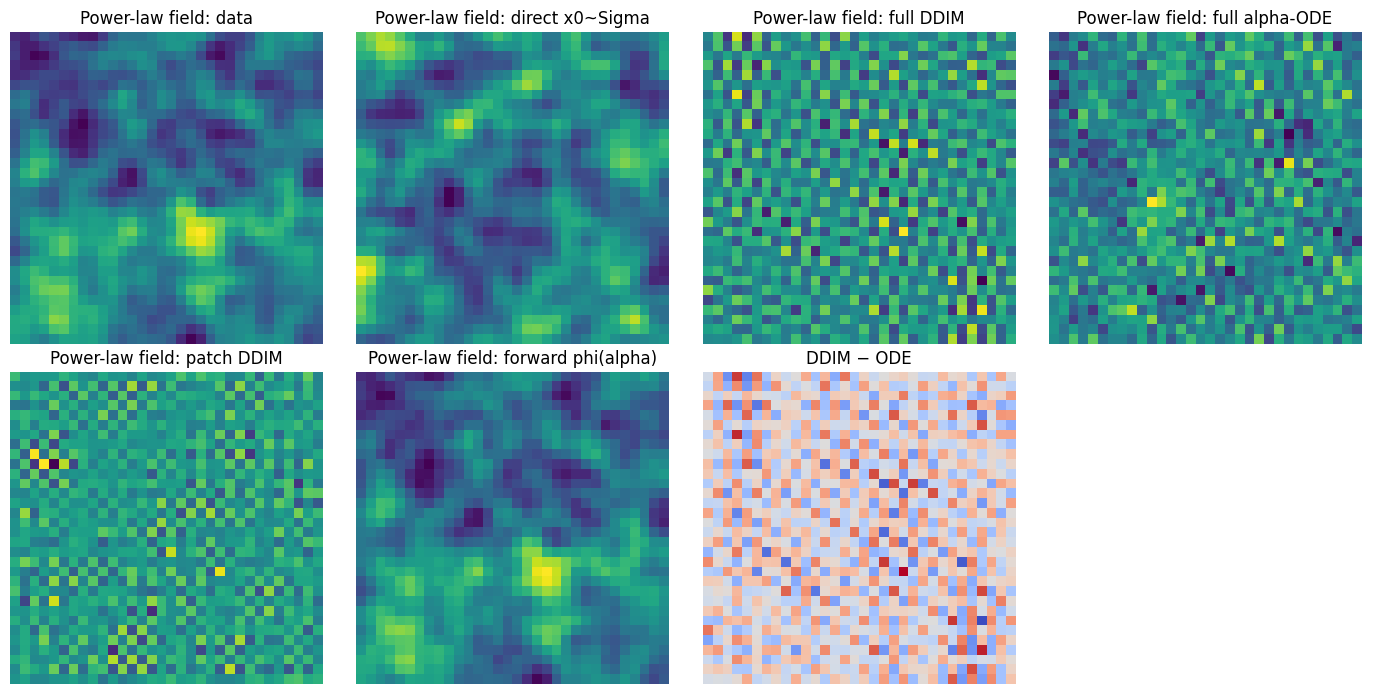

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
panels = [
    (data_images[0, 0].cpu(), "data"),
    (gen_direct[0, 0].cpu(), "direct x0~Sigma"),
    (gen_images_full[0, 0].cpu(), "full DDIM"),
    (gen_full_ode[0, 0].cpu(), "full alpha-ODE"),
]
for j, (img, title) in enumerate(panels):
    axes[0, j].imshow(img, cmap="viridis")
    axes[0, j].set_title(f"{dataset_name}: {title}")
    axes[0, j].axis("off")
axes[1, 0].imshow(gen_images_patch[0, 0].cpu(), cmap="viridis")
axes[1, 0].set_title(f"{dataset_name}: patch DDIM")
axes[1, 0].axis("off")
axes[1, 1].imshow(phi_forward_last[0, 0].cpu(), cmap="viridis")
axes[1, 1].set_title(f"{dataset_name}: forward phi(alpha)")
axes[1, 1].axis("off")
axes[1, 2].imshow((gen_images_full[0, 0] - gen_full_ode[0, 0]).cpu(), cmap="coolwarm")
axes[1, 2].set_title("DDIM − ODE")
axes[1, 2].axis("off")
axes[1, 3].axis("off")
plt.tight_layout()
plt.show()

## Covariance comparison (processing)

Radial binning of Fourier power \(P(k)\) vs \(|k|\): theory from \(\Sigma\), empirical from data/generated samples.

In [8]:
C_theory = C_full.detach().cpu().double()

fro_data = torch.linalg.norm(C_emp_data - C_theory).item()
fro_gen = torch.linalg.norm(C_emp_gen - C_theory).item()
fro_data_norm = fro_data / torch.linalg.norm(C_theory).item()
fro_gen_norm = fro_gen / torch.linalg.norm(C_theory).item()

_, bin_idx, k_centers, _ = radial_power_bins(image_height, image_width, device="cpu")
n_bins = len(k_centers)

power_theory = radial_power_from_covariance(C_theory, image_height, image_width, bin_idx, n_bins)
power_data = radial_power_from_images(data_images, bin_idx, n_bins)
power_gen = radial_power_from_images(gen_images, bin_idx, n_bins)
power_ref = theory_radial_power(k_centers, alpha, amplitude=amplitude)

spectrum_results = {
    "k_centers": k_centers,
    "power_theory": power_theory,
    "power_data": power_data,
    "power_gen": power_gen,
    "power_ref": power_ref,
}

print(f"{dataset_name}: Frobenius rel error  data vs theory: {fro_data_norm:.4f}")
print(f"{dataset_name}: Frobenius rel error  gen vs theory: {fro_gen_norm:.4f}")

Power-law field: Frobenius rel error  data vs theory: 0.1333
Power-law field: Frobenius rel error  gen vs theory: 0.4748


## Plots

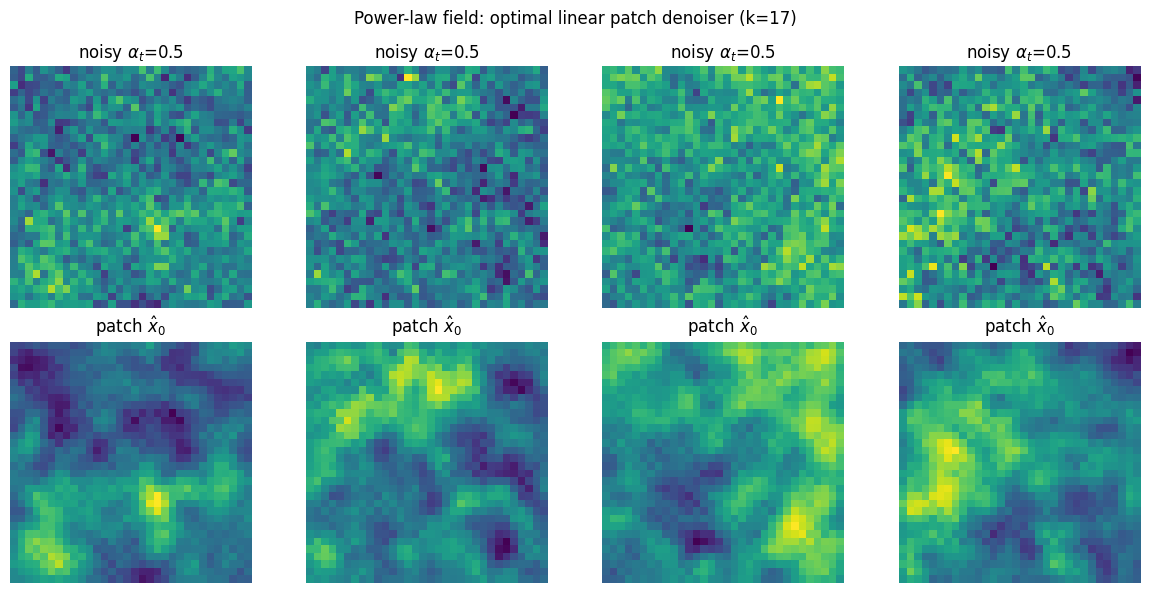

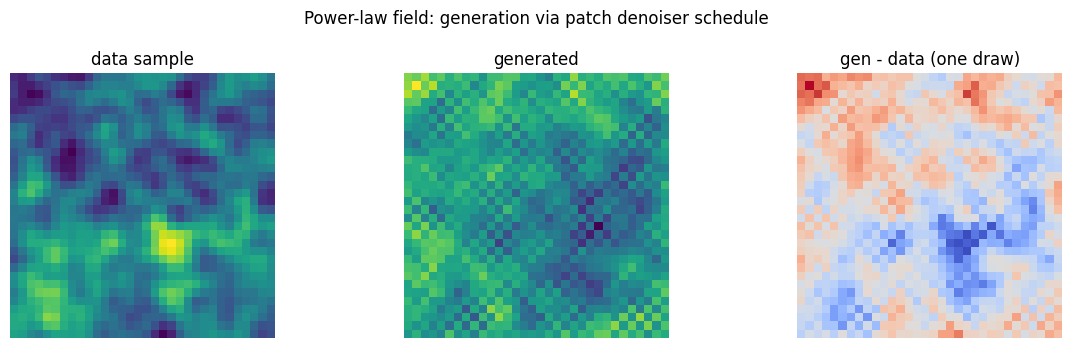

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(min(4, phi_demo.shape[0])):
    axes[0, i].imshow(phi_demo[i, 0].cpu(), cmap="viridis")
    axes[0, i].set_title(f"noisy $\\alpha_t$={alpha_t_demo}")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_hat_demo[i, 0].cpu(), cmap="viridis")
    axes[1, i].set_title("patch $\\hat x_0$")
    axes[1, i].axis("off")
fig.suptitle(f"{dataset_name}: optimal linear patch denoiser (k={k_demo})")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(data_images[0, 0].cpu(), cmap="viridis")
axes[0].set_title("data sample")
axes[0].axis("off")
axes[1].imshow(gen_images[0, 0].cpu(), cmap="viridis")
axes[1].set_title("generated")
axes[1].axis("off")
axes[2].imshow((gen_images[0, 0] - data_images[0, 0]).cpu(), cmap="coolwarm")
axes[2].set_title("gen - data (one draw)")
axes[2].axis("off")
fig.suptitle(f"{dataset_name}: generation via patch denoiser schedule")
plt.tight_layout()
plt.show()

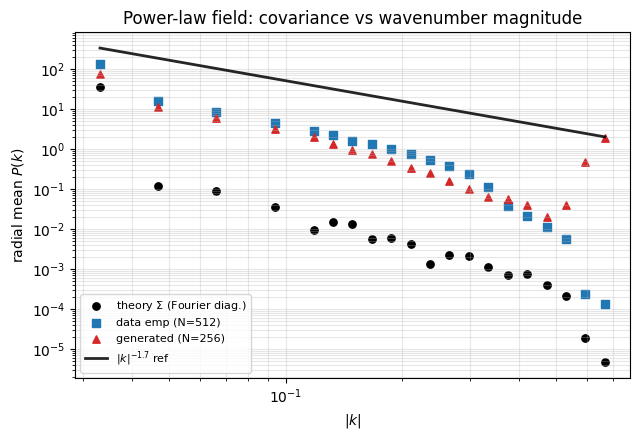

In [10]:
k_centers = spectrum_results["k_centers"]
mask = k_centers > 0

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.5))
k = k_centers[mask]
ax.scatter(k, spectrum_results["power_theory"][mask], s=28, c="k", marker="o", label=r"theory $\Sigma$ (Fourier diag.)")
ax.scatter(k, spectrum_results["power_data"][mask], s=28, c="tab:blue", marker="s", label=f"data emp (N={n_data_samples})")
ax.scatter(k, spectrum_results["power_gen"][mask], s=28, c="tab:red", marker="^", label=f"generated (N={n_gen_samples})")
ax.loglog(k, spectrum_results["power_ref"][mask], "k-", lw=2, alpha=0.85, label=rf"$|k|^{{-{alpha}}}$ ref")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$|k|$")
ax.set_ylabel(r"radial mean $P(k)$")
ax.set_title(f"{dataset_name}: covariance vs wavenumber magnitude")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()